# LLM 발전 흐름
통계기반 → RNN → Transformer → 대규모 사전학습

# 모델 연표로 보는 발전 추세
모델 연표 데이터(`model_timeline.csv`)로 연도별 파라미터 추세를 그래프로 그려, "모델이 어떻게 커져 왔는지"를 눈으로 확인합니다.

### 0. 준비

In [ ]:
#!pip install -q pandas matplotlib   # matplotlib: 그래프를 그리는 표준 시각화 라이브러리
from google.colab import drive
drive.mount('/content/drive')        # 드라이브 연결(연표 CSV를 읽기 위해)
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt   # plt: matplotlib.pyplot의 관례적 별칭
ROOT = Path('/content/drive/MyDrive/kt cloud tech up/gen-ai'); DATA = ROOT / 'data'

Mounted at /content/drive


### 1. 연표 데이터 로드
해당 표는 교육용 근사치이며, 일부 모델은 파라미터가 비공개(`NaN`)입니다.

In [ ]:
df = pd.read_csv(DATA / 'model_timeline.csv')   # 모델 연표 CSV를 표로 읽기
df   # 열: model, release_year, params_b(파라미터 수·십억), family, arch, open_source, org

,model,release_year,params_b,family,arch,open_source,org
0,BERT-base,2018,0.11,BERT,encoder,예,Google
1,GPT-2,2019,1.50,GPT,decoder,예,OpenAI
2,T5-11B,2019,11.00,T5,encoder-decoder,예,Google
3,GPT-3,2020,175.00,GPT,decoder,아니오,OpenAI
4,LLaMA,2023,65.00,LLaMA,decoder,예,Meta
5,LLaMA 2,2023,70.00,LLaMA,decoder,예,Meta
6,Mistral 7B,2023,7.00,Mistral,decoder,예,Mistral AI
7,GPT-4,2023,NaN,GPT,decoder,아니오,OpenAI
8,Gemini 1.0,2023,NaN,Gemini,decoder,아니오,Google
9,Gemini 1.5,2024,NaN,Gemini,decoder,아니오,Google


### 2. 파라미터 추세 산점도 (로그 스케일)

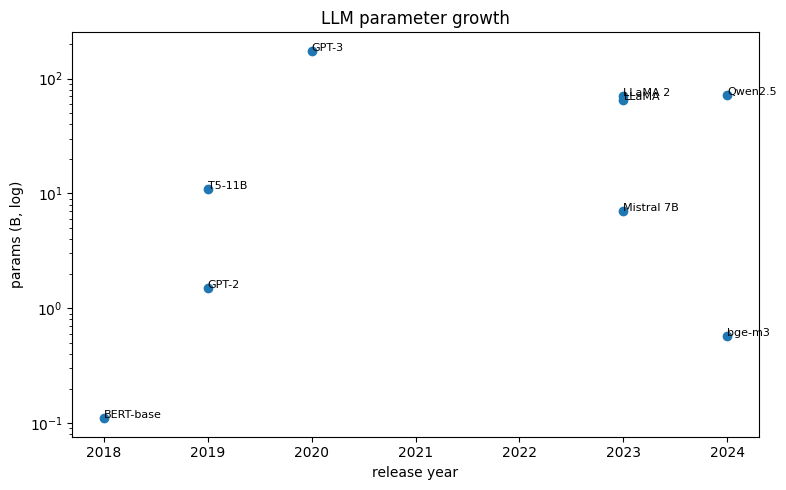

In [ ]:
# params_b(파라미터 수)가 비어 있는 행은 그래프에서 제외(dropna), 원본 보호 위해 .copy()
d = df.dropna(subset=['params_b']).copy()
d['params_b'] = pd.to_numeric(d['params_b'], errors='coerce')  # 문자열→숫자 변환(실패하면 NaN)
d = d.dropna(subset=['params_b'])                              # 변환 실패(NaN)한 행도 제거

plt.figure(figsize=(8, 5))                       # 그림판 크기(가로 8 · 세로 5 인치)
plt.scatter(d['release_year'], d['params_b'])    # 산점도: x=출시연도, y=파라미터 수, 점 하나=모델 하나
for _, r in d.iterrows():                         # 각 점 옆에 모델 이름 라벨을 단다
    plt.annotate(r['model'], (r['release_year'], r['params_b']), fontsize=8)
plt.yscale('log')                 # y축 로그 스케일 — 파라미터가 기하급수적으로 커져 로그가 적합
plt.xlabel('release year'); plt.ylabel('params (B, log)')   # 축 이름
plt.title('LLM parameter growth'); plt.tight_layout(); plt.show()   # 제목·여백정리·화면출력

-> y축이 로그임에도 우상향합니다. 즉 모델의 파라미터가 기하급수적으로 커져 왔다는 의미입니다

### 3. 오픈/클로즈드 비교

In [ ]:
# value_counts(): 한 열의 값별 개수를 세어 준다 → 오픈소스 vs 클로즈드 모델 분포 확인
print(df['open_source'].value_counts())

open_source
예      8
아니오    5
Name: count, dtype: int64


# Hugging Face
앞써 확인한 모들들은 Hugging Face(허깅페이스)에서 무료로 공개하므로, 처음부터 학습할 필요 없이 내려받아 사용할 수 있습니다.
* 모델 이름은 올린주체/모델이름(klue/bert-base), transformers 의 from_pretrained('이름') 한 줄로 다운로드·캐시·로드합니다.
* 모델 카드(설명서)로 언어·라이선스·용도를 확인하고, `huggingface_hub`로 메타를 조회합니다.

In [ ]:
from transformers import AutoModel, AutoTokenizer
# from_pretrained('이름') 이 하는 일:
#  ① 허깅페이스 서버에 접속해 그 모델 파일(가중치·설정·토크나이저)을 다운로드
#  ② 내 컴퓨터(코랩)의 캐시 폴더(~/.cache)에 저장 — 다음부터는 다시 안 받고 재사용
#  ③ 파이썬 메모리로 불러와 바로 쓸 수 있게 준비
tok = AutoTokenizer.from_pretrained('klue/bert-base')    # 그 모델 전용 토크나이저
model = AutoModel.from_pretrained('klue/bert-base')       # 모델 본체(가중치)